In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


In [24]:
files_2 = pd.ExcelFile("activity.xlsx")

In [25]:
print(files_2.sheet_names)

['people_in_hospital', 'people_in_hospital_by_state', 'sameday_or_overnight', 'patients_day', 'avg_patients_day', 'Patient _days_ per_1,000', 'Separation_state_1000']


In [26]:

people_in_hospital = pd.read_excel("activity.xlsx", sheet_name="people_in_hospital")

In [27]:
people_in_hospital

,Hospital_Type,Category,Year,Separations
0,Public hospitals,Public acute hospitals,2019–20,6716770
1,Public hospitals,Public acute hospitals,2020–21,6956417
2,Public hospitals,Public acute hospitals,2021–22,6827068
3,Public hospitals,Public acute hospitals,2022–23,7117715
4,Public hospitals,Public acute hospitals,2023–24,7468059
5,Public hospitals,Public psychiatric hospitals,2019–20,13272
6,Public hospitals,Public psychiatric hospitals,2020–21,12770
7,Public hospitals,Public psychiatric hospitals,2021–22,10027
8,Public hospitals,Public psychiatric hospitals,2022–23,10290
9,Public hospitals,Public psychiatric hospitals,2023–24,11349


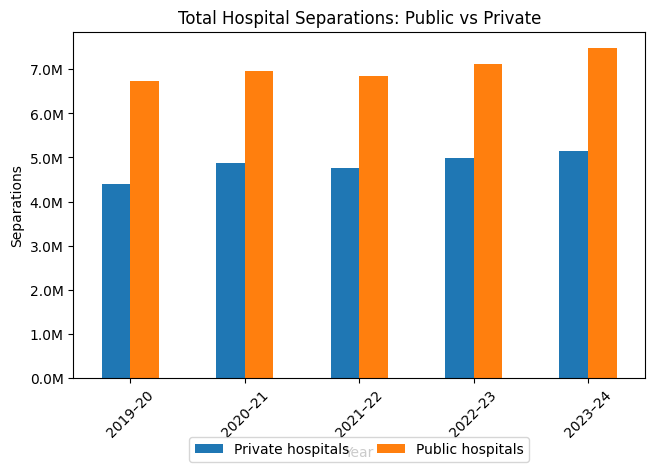

In [ ]:
pivot = people_in_hospital[people_in_hospital["Category"].str.contains("Total")].pivot(
    index="Year",
    columns="Hospital_Type",
    values="Separations"
)

pivot.plot(kind="bar")

plt.title("Total Hospital Separations: Public vs Private")
plt.ylabel("Separations")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.tight_layout()
# format y-axis to millions
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)
# legend under the chart (center)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()